OBJECTIVE: use machine learning to create a model that predicts which passengers survived the Titanic shipwreck.

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

In [144]:
import pandas as pd

In [145]:
# Import training set
df = pd.read_csv("/Users/alinemitri/Documents/Machine Learning/hands-on-ML-book/datasets/titanic/train.csv")

In [146]:
# Verify first rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [147]:
# Verify columns' types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Observations
- 7 numerical features
- 5 categorical features
- Survived is the label: 0 = no, 1 = yes
- Name is irrelevant
- Age has 19.9% of missing values
- SibSp means number of siblings/spouses aboard the Titanic
- Parch maeans number of parents/children aboard the Titanic
- Ticket number seems irrelevant
- Cabin has 77% of missing values
- Embarked has 2 missing values; C = Cherbourg, Q = Queenstown, S = Southampton

In [148]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [149]:
# Transform Pclass values to categorical values
df["Pclass"] = df["Pclass"].map({1: "A", 2: "B", 3: "C"})

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 83.7+ KB


How to deal with missing values in Age?
- Compute the median of male and female ages
- Change missing values to the median age, according to the sex of the person.

In [151]:
# Compute median
medians = df.groupby("Sex")["Age"].median()
print(medians)

Sex
female    27.0
male      29.0
Name: Age, dtype: float64


In [152]:
# Change missing values to the median age
df["Age"] = df.groupby("Sex")["Age"].transform(lambda x: x.fillna(x.median()))

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 83.7+ KB


In [154]:
# Modify NaN Embarked values to NA
import numpy as np
df["Embarked"] = df["Embarked"].replace(np.nan, "U")

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 83.7+ KB


In [156]:
df["Relatives"] = df["SibSp"] + df["Parch"]

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
 12  Relatives    891 non-null    int64  
dtypes: float64(2), int64(5), object(6)
memory usage: 90.6+ KB


In [158]:
# Drop features
features = [
    "PassengerId",
    "Name",
    "SibSp",
    "Parch",
    "Ticket",
    "Cabin",
]

df_train = df.drop(features, axis=1)

In [159]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   891 non-null    int64  
 1   Pclass     891 non-null    object 
 2   Sex        891 non-null    object 
 3   Age        891 non-null    float64
 4   Fare       891 non-null    float64
 5   Embarked   891 non-null    object 
 6   Relatives  891 non-null    int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 48.9+ KB


In [160]:
# Verify distribution of features according to labels
numerical_features = [
    "Age",
    "Relatives",
    "Fare",
]

for var in numerical_features:
    print(var)
    print(df_train.groupby("Survived")[var].describe().round(2))

Age
          count   mean    std   min   25%   50%   75%   max
Survived                                                   
0         549.0  30.19  12.48  1.00  23.0  29.0  35.0  74.0
1         342.0  28.23  13.77  0.42  21.0  27.0  35.0  80.0
Relatives
          count  mean   std  min  25%  50%  75%   max
Survived                                             
0         549.0  0.88  1.83  0.0  0.0  0.0  1.0  10.0
1         342.0  0.94  1.19  0.0  0.0  1.0  2.0   6.0
Fare
          count   mean    std  min    25%   50%   75%     max
Survived                                                     
0         549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
1         342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33


array([[<Axes: xlabel='Age', ylabel='Age'>,
        <Axes: xlabel='Relatives', ylabel='Age'>,
        <Axes: xlabel='Fare', ylabel='Age'>],
       [<Axes: xlabel='Age', ylabel='Relatives'>,
        <Axes: xlabel='Relatives', ylabel='Relatives'>,
        <Axes: xlabel='Fare', ylabel='Relatives'>],
       [<Axes: xlabel='Age', ylabel='Fare'>,
        <Axes: xlabel='Relatives', ylabel='Fare'>,
        <Axes: xlabel='Fare', ylabel='Fare'>]], dtype=object)

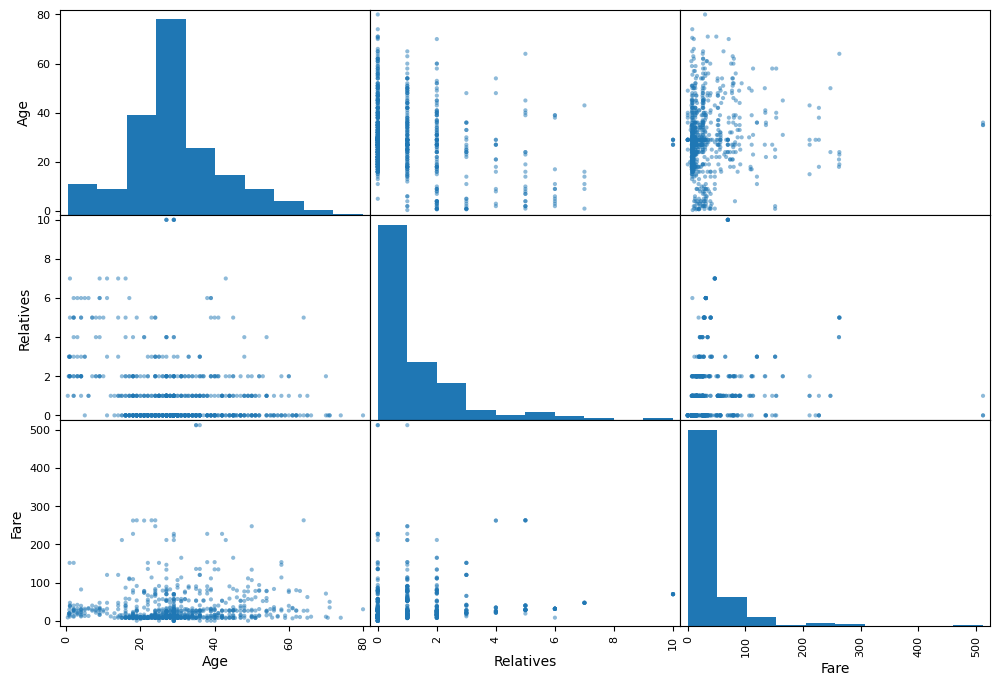

In [161]:
# Check for correlation with scatter_matrix 
from pandas.plotting import scatter_matrix
scatter_matrix(df_train[numerical_features], figsize=(12,8))

Machine Learning Models

In [165]:
# Create training set and label
y_train = df_train["Survived"].copy()
X_train = df_train.drop("Survived", axis=1)

In [166]:
X_train.shape

(891, 6)

In [ ]:
#Create one binary attribute per category
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

X_train = cat_encoder.fit_transform(X_train)

In [168]:
X_train.shape

(891, 354)

SGD Classifier

In [95]:
# Create the Stochastic Gradient Descent (SGD) classifier
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42, n_jobs=-1)
sgd_clf.fit(X_train, y_train)

SGDClassifier(n_jobs=-1, random_state=42)

In [96]:
#Measure accuracy using cross-validation
from sklearn.model_selection import cross_val_score, cross_val_predict
cross_val_score(sgd_clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

array([0.81005587, 0.78089888, 0.80898876, 0.80898876, 0.79213483])

In [97]:
#Threshold selection
y_scores = cross_val_predict(sgd_clf, X_train, y_train, cv=5, method='decision_function')

In [98]:
y_scores

array([-8.19378193e-01,  4.70359474e+00,  4.17759732e+00,  4.70359474e+00,
       -5.56379481e-01, -2.39737046e+00, -2.93380770e-01, -6.86834855e+00,
        4.44059603e+00,  4.44059603e+00,  7.33358186e+00,  4.17759732e+00,
       -5.56379481e-01, -5.81635371e+00,  2.59960505e+00, -1.08237690e+00,
       -5.02735757e+00, -1.34537562e+00,  1.54761021e+00,  4.44059603e+00,
       -1.08237690e+00, -1.08237690e+00,  4.70359474e+00,  1.02161279e+00,
       -1.34537562e+00,  3.38860119e+00, -8.19378193e-01, -3.03820588e-02,
        4.70359474e+00, -2.66036917e+00,  2.32616653e-01,  6.54458572e+00,
        2.86260377e+00, -1.87137304e+00,  1.28461150e+00,  1.28461150e+00,
       -1.60837433e+00, -2.39737046e+00,  1.28461150e+00,  3.38860119e+00,
        2.86260377e+00,  2.59960505e+00, -1.08237690e+00,  5.22959217e+00,
        4.70359474e+00, -1.60837433e+00, -3.44936531e+00,  2.86260377e+00,
       -1.60837433e+00,  1.81060892e+00, -4.50136015e+00, -3.18636659e+00,
        6.54458572e+00,  

In [99]:
y_pred = y_scores >= -2

In [100]:
sgd_clf.predict(X_train[10])

array([1])

In [101]:
sgd_clf.decision_function(X_train[10])

array([4.73709215])

In [102]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train, y_scores)

In [103]:
import matplotlib.pyplot as plt

In [104]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)                             

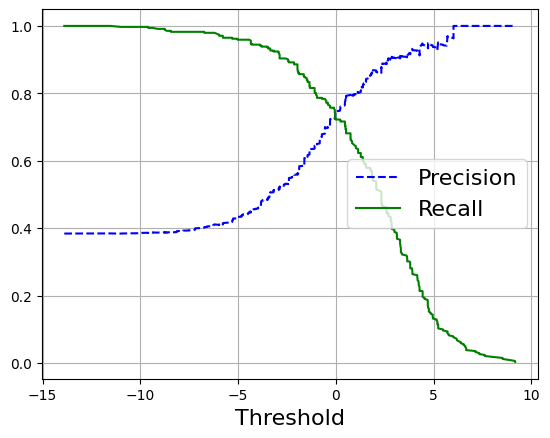

In [105]:
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [106]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train, y_scores)

In [107]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') #dashed diagonal
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.grid(True)

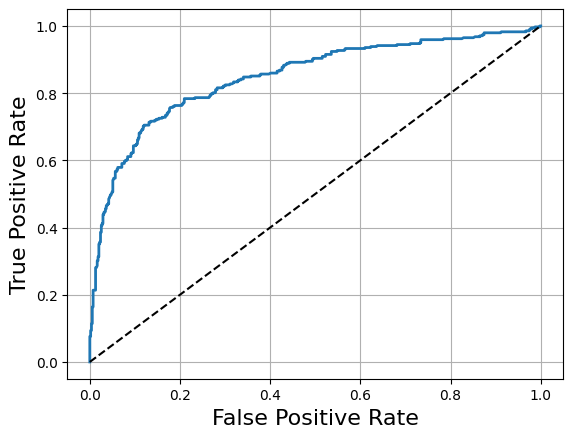

In [108]:
plot_roc_curve(fpr, tpr)
plt.show()

In [109]:
#Area under the curve (AUC)
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train, y_scores)

np.float64(0.8482035385975564)

In [110]:
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train, cv=5, n_jobs=-1)

In [111]:
from sklearn.metrics import confusion_matrix
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[466,  83],
       [ 95, 247]])

In [112]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

precision_score(y_train, y_train_pred)

0.7484848484848485

In [113]:
recall_score(y_train, y_train_pred)

0.7222222222222222

In [114]:
f1_score(y_train, y_train_pred)

0.7351190476190477

In [115]:
accuracy_score(y_train, y_train_pred)

0.8002244668911336

Random Forest Classifier

In [116]:
# Create a Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
forest_clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [117]:
cross_val_score(forest_clf, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

array([0.79329609, 0.79775281, 0.84831461, 0.79213483, 0.81460674])

In [118]:
y_prob_forest = cross_val_predict(forest_clf, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)

In [119]:
y_scores_forest = y_prob_forest[:,1]

fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train, y_scores_forest)

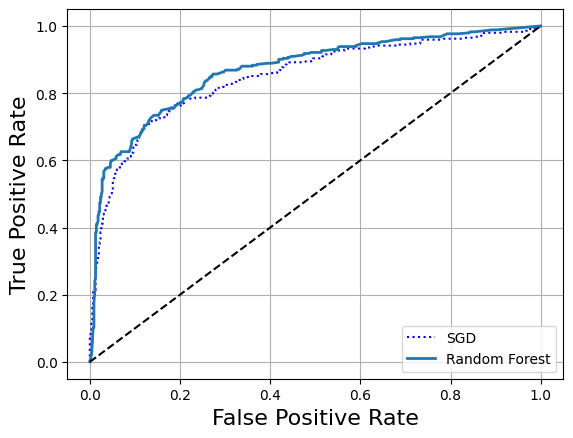

In [120]:
plt.plot(fpr, tpr, 'b:', label='SGD')
plot_roc_curve(fpr_forest, tpr_forest, 'Random Forest')
plt.legend(loc='lower right')
plt.show()

In [121]:
roc_auc_score(y_train, y_scores_forest)

np.float64(0.868801861971261)

In [122]:
y_pred_fc = cross_val_predict(forest_clf, X_train, y_train, cv=3, n_jobs=-1)
confusion_matrix(y_train, y_pred_fc)

KeyboardInterrupt: 

In [ ]:
accuracy_score(y_train, y_pred_fc)

0.7934904601571269

In [ ]:
precision_score(y_train, y_pred_fc)

0.778169014084507

In [ ]:
recall_score(y_train, y_pred_fc)

0.6461988304093568

In [ ]:
f1_score(y_train, y_pred_fc)

0.7060702875399361

In [ ]:
#Fine-tune Random Forest Model with Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_estimators": [50, 125, 250, 500]},
    {"bootstrap": [False], "n_estimators": [125, 250, 500]},
]

grid_search = GridSearchCV(forest_clf, param_grid, cv=5,
                           scoring="accuracy",
                           return_train_score=True,
                           n_jobs=-1
                           )

grid_search.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid=[{'n_estimators': [50, 125, 250, 500]},
                         {'bootstrap': [False],
                          'n_estimators': [125, 250, 500]}],
             return_train_score=True, scoring='accuracy')

In [ ]:
forest_clf_better = RandomForestClassifier(n_estimators=125, random_state=42, n_jobs=-1)
forest_clf_better.fit(X_train, y_train)

RandomForestClassifier(n_estimators=125, n_jobs=-1, random_state=42)

In [ ]:
cross_val_score(forest_clf_better, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)

array([0.7877095 , 0.80337079, 0.84831461, 0.78651685, 0.82022472])

In [ ]:
y_pred_fcb = cross_val_predict(forest_clf_better, X_train, y_train, cv=3, n_jobs=-1)
confusion_matrix(y_train, y_pred_fcb)

array([[485,  64],
       [121, 221]])

In [ ]:
accuracy_score(y_train, y_pred_fcb)

0.792368125701459

In [ ]:
precision_score(y_train, y_pred_fcb)

0.775438596491228

In [ ]:
recall_score(y_train, y_pred_fcb)

0.6461988304093568

In [ ]:
f1_score(y_train, y_pred_fcb)

0.7049441786283892

In [ ]:
y_prob_fcb = cross_val_predict(forest_clf_better, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)
y_scores_fcb= y_prob_fcb[:,1]

fpr_fcb, tpr_fcb, thresholds_fcb = roc_curve(y_train, y_scores_fcb)

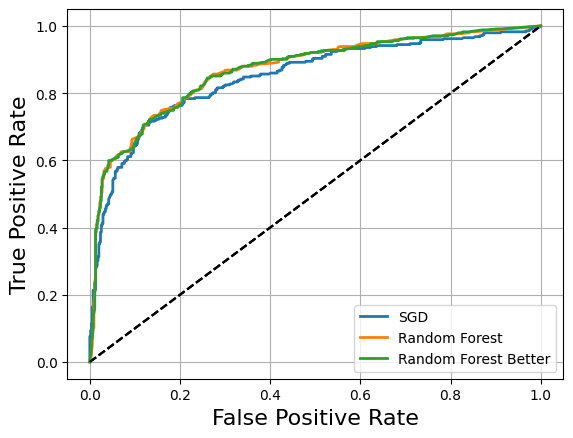

In [ ]:
plot_roc_curve(fpr, tpr, 'SGD')
plot_roc_curve(fpr_forest, tpr_forest, 'Random Forest')
plot_roc_curve(fpr_fcb, tpr_fcb, 'Random Forest Better')
plt.legend(loc='lower right')
plt.show()

Support Vector Machine

In [ ]:
from sklearn import svm

svm_clf = svm.SVC()
svm_clf.fit(X_train, y_train)

SVC()

In [ ]:
y_pred_svm = cross_val_predict(svm_clf, X_train, y_train, cv=5, n_jobs=-1)
confusion_matrix(y_train, y_pred_svm)

array([[511,  38],
       [129, 213]])

In [ ]:
accuracy_score(y_train, y_pred_svm)

0.8125701459034792

In [ ]:
precision_score(y_train, y_pred_svm)

0.848605577689243

In [ ]:
recall_score(y_train, y_pred_svm)

0.6228070175438597

In [ ]:
f1_score(y_train, y_pred_svm)

0.718381112984823

In [ ]:
y_scores_svm = cross_val_predict(svm_clf, X_train, y_train, cv=5, method='decision_function', n_jobs=-1)

In [ ]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_train, y_scores_svm)

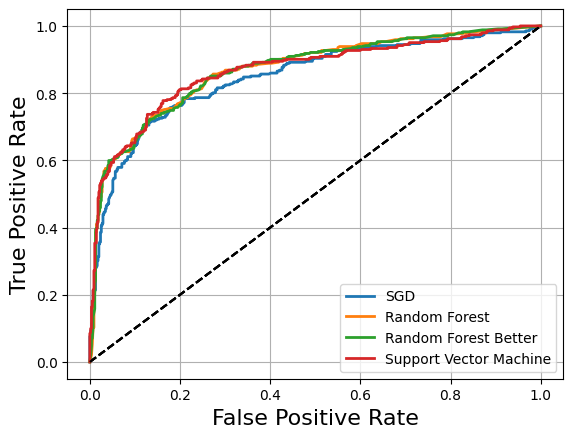

In [ ]:
plot_roc_curve(fpr, tpr, 'SGD')
plot_roc_curve(fpr_forest, tpr_forest, 'Random Forest')
plot_roc_curve(fpr_fcb, tpr_fcb, 'Random Forest Better')
plot_roc_curve(fpr_svm, tpr_svm, 'Support Vector Machine')
plt.legend(loc='lower right')
plt.show()